In [ ]:
import pandas as pd        
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns      

df = pd.read_csv("../data/train.csv")

df.head()   #shows first 5 rows of data
print(df.shape)  #shows a tuple of (rows, columns) in this dataset (891, 12) means 891 passengers with 12 columns of info
df.info()   #for each column it shows its name, data type, non null count (how many values are not null)

(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

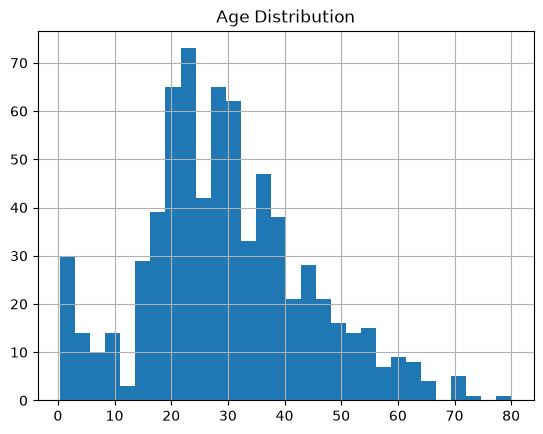

In [4]:
df['Age'].hist(bins=30)
plt.title('Age Distribution')
plt.show()

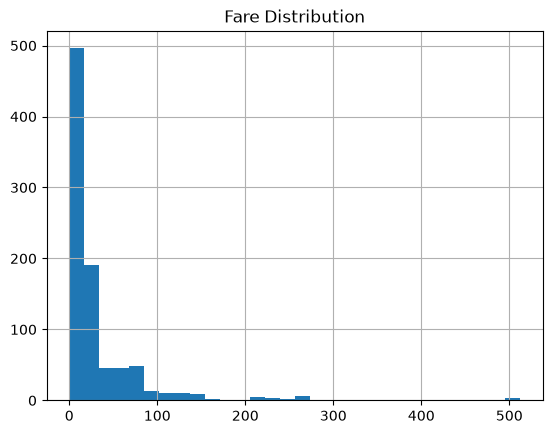

In [7]:
df['Fare'].hist(bins=30)
plt.title('Fare Distribution')
plt.show()

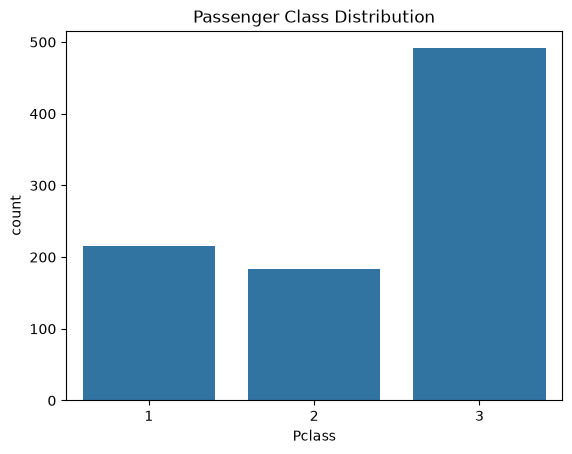

In [8]:
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()

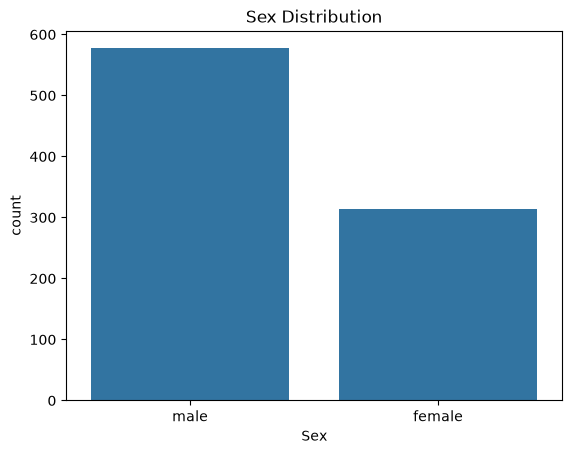

In [9]:
sns.countplot(x='Sex', data=df)
plt.title('Sex Distribution')
plt.show()

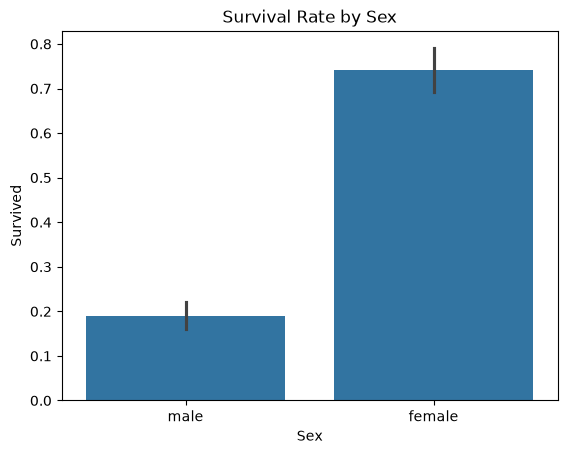

In [10]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()

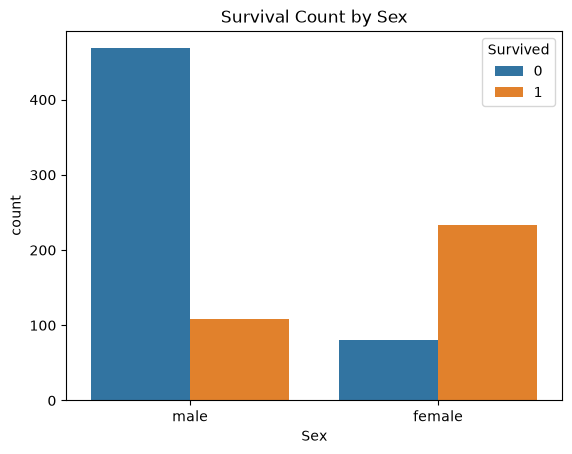

In [11]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Sex')
plt.show()

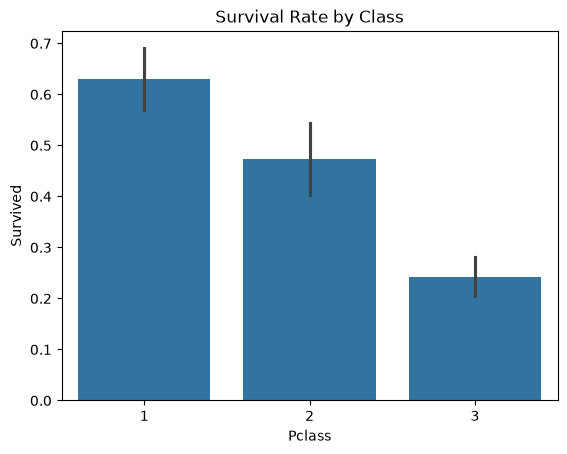

In [12]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Class')
plt.show()

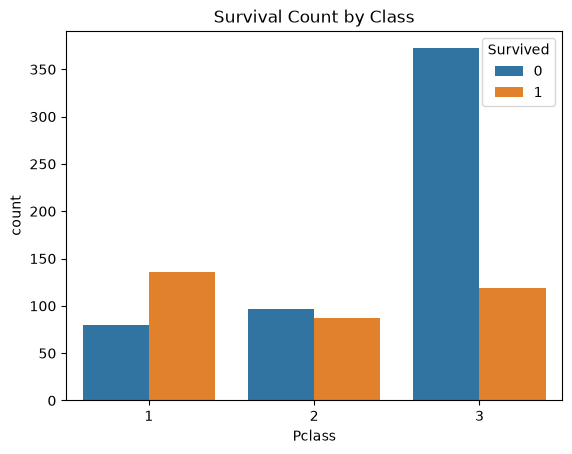

In [13]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival Count by Class')
plt.show()

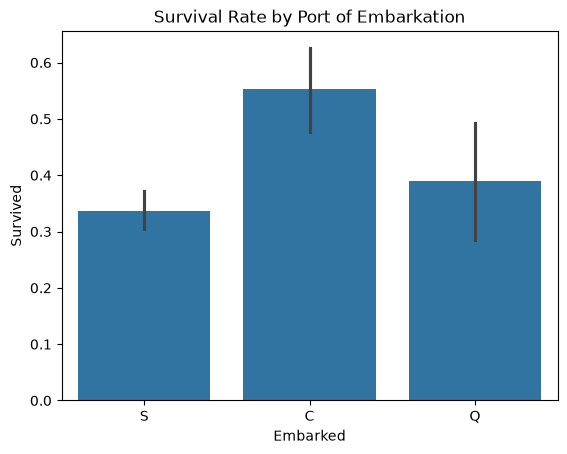

In [14]:
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Survival Rate by Port of Embarkation')
plt.show()

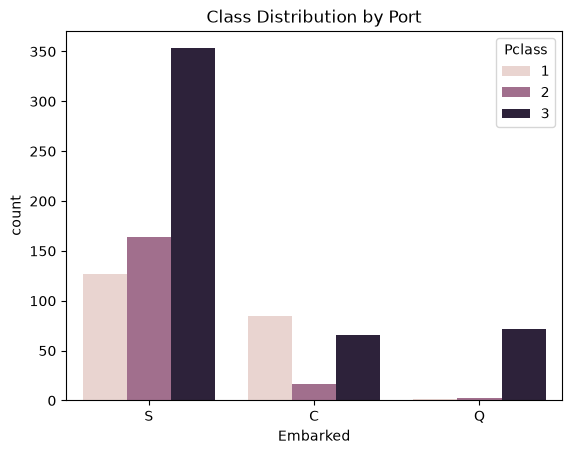

In [15]:
sns.countplot(x='Embarked', hue='Pclass', data=df)
plt.title('Class Distribution by Port')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

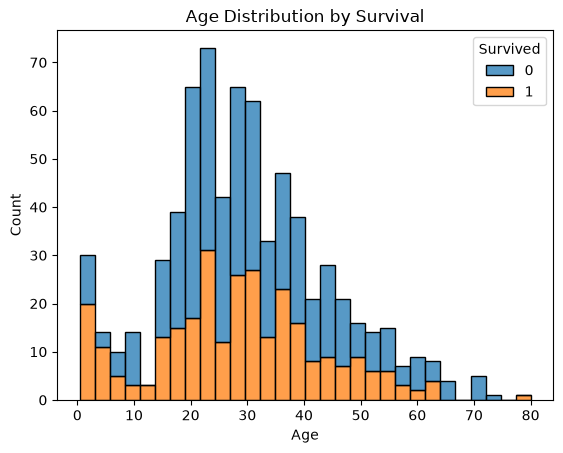

In [16]:
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=30)
plt.title('Age Distribution by Survival')
plt.show

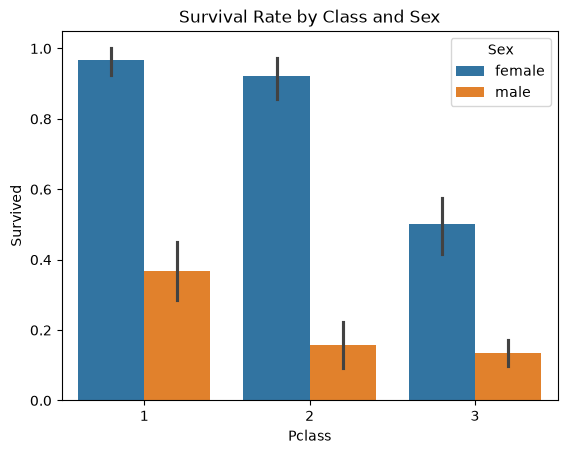

In [17]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.title('Survival Rate by Class and Sex')
plt.show()

In [18]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


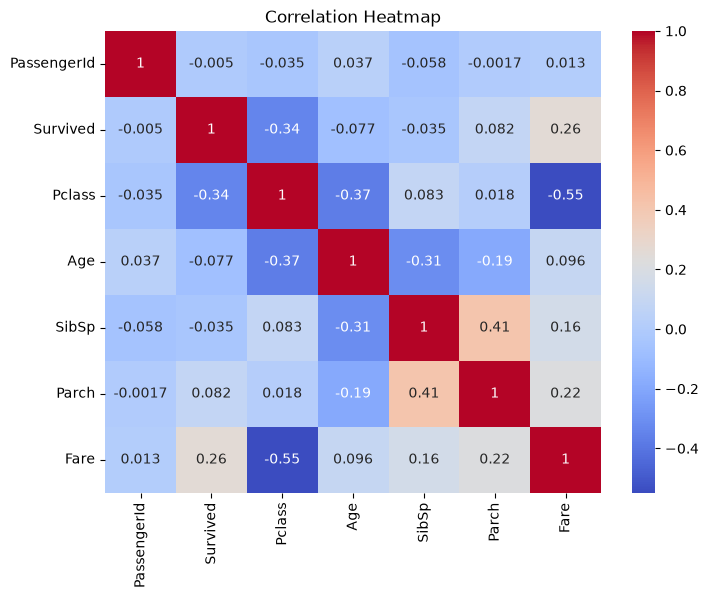

In [19]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Titanic Survival Prediction - Exploratory Data Analysis

This notebook explores the Titanic Dataset (Kaggle competition) its aim is to understand patterns in passenger survival before building predictive models.

**DATASET**  The Training dataset consists of information (sex, age, class etc..) for 891 passengers.

**GOAL** Identify which features (sex, age, class etc..) are most associated with passenger survival and understand data quality (missing values, outliers) that will need to be addressed in preprocessing.

**KEY FINDINGS** 
- Baseline accuracy (always predict passenger didnt survive) is 549/891 = 61.6% - any real model need to confidently beat this.
- Sex is the strongest indicator of survival : Women ~ 74%, Men ~ 19%
- Pclass matters a lot: 1st class ~ 63%, 3rd class ~ 24%
- The combination of sex and pclass is vital : 1st class Women ~ 97%, 3rd class Men ~ 13%
- Embarked acts as a proxy for class : Cherbourg has a higher proportion of 1st class passengets than other ports
- Age shows a "children first" policy was followed leading to high survival rates.
- Missing Data: Age (177), Cabin (687), Embarked (2)
- Cabin is too sparse to be used directly 